### Based on Wavenet paper by Deepmind

In [37]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [38]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-03-23 08:49:55--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.1’

names.txt.1         100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-03-23 08:49:56 (13.9 MB/s) - ‘names.txt.1’ saved [228145/228145]



In [39]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [40]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [41]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [42]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [43]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [49]:
## Mimicing the Pytorch API

class Linear:
  def __init__(self, in_features, out_features, bias=True):
    self.w = torch.randn(in_features, out_features) / in_features**0.5
    self.b = torch.zeros(out_features) if bias else None

  def __call__(self, x):
    self.out = x @ self.w
    if self.b is not None:
      self.out += self.b
    return self.out

  def parameters(self):
    return [self.w] + ([self.b] if self.b is not None else [])

class BatchNorm1d:
  def __init__(self, num_features, eps=1e-5, momentum=0.001):
    self.bngain = torch.ones(num_features)
    self.bnbias = torch.zeros(num_features)
    self.training = True
    self.bnmean_running = torch.zeros(num_features)
    self.bnvar_running = torch.ones(num_features)
    self.eps = eps
    self.momentum = momentum

  def __call__(self, x):
    if self.training:
      bnmean = x.mean(dim=0, keepdim=True)
      bnvar = x.var(dim=0, keepdim=True)
    else:
      bnmean = self.bnmean_running
      bnvar = self.bnvar_running

    # Normalize the output after linear and before non-linear
    self.out = self.bngain * ((x-bnmean)/torch.sqrt(bnvar + self.eps)) + self.bnbias

    # Keep on adjusting overall mean and std, so that it could be used during evalutation or inference
    if self.training:
      with torch.no_grad():
        self.bnmean_running = (1-self.momentum)*self.bnmean_running + self.momentum*bnmean
        self.bnvar_running = (1-self.momentum)*self.bnvar_running + self.momentum*bnvar

    return self.out

  def parameters(self):
    return [self.bngain, self.bnbias]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

In [50]:
torch.manual_seed(42)

In [75]:
n_embd = 10
n_hidden = 100

layers = [
    Linear(block_size*n_embd, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

C = torch.randn(vocab_size, n_embd)
parameters = [C] + [p for layer in layers for p in layer.parameters()]

with torch.no_grad():
  layers[-1].w *= 0.1

for p in parameters:
  p.requires_grad = True

print(sum([p.nelement() for p in parameters]))

11197


In [76]:
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  idx = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[idx], Ytr[idx]

  emb = C[Xb]
  x = emb.view(emb.shape[0], -1)
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, Yb)

  #Backward
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} {loss.item():.4f}")
  lossi.append(loss.item())

0/200000 3.2972
10000/200000 2.1340
20000/200000 2.1703
30000/200000 2.2476
40000/200000 2.0998
50000/200000 2.0095
60000/200000 2.2080
70000/200000 2.0424
80000/200000 2.0685
90000/200000 2.1411
100000/200000 2.0435
110000/200000 1.5082
120000/200000 2.2242
130000/200000 2.1368
140000/200000 2.0035
150000/200000 1.7651
160000/200000 1.9022
170000/200000 1.8436
180000/200000 2.3792
190000/200000 2.4060


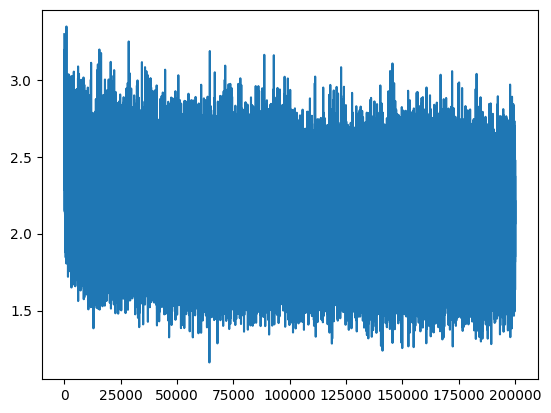

In [77]:
plt.plot(lossi)

In [78]:
layers[1].training = False

In [79]:
# Set training to False
#for layer in layers:
#  layer.training = False

# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]

  emb = C[x]
  x = emb.view(emb.shape[0], -1)
  for layer in layers:
    x = layer(x)
  logits = x
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.007739305496216
val 2.0643043518066406


In [83]:
# Inference

for _ in range(20):
  out = []
  context = [0]*block_size

  while True:
    emb = C[torch.tensor([context])]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
      x = layer(x)
    logits = x
    probs = F.softmax(logits, dim=1)
    idx = torch.multinomial(probs, num_samples=1, replacement=True).item()
    context = context[1:] + [idx] # Shifting by 1
    if idx == 0:
      break
    else:
      out.append(idx)
  print("".join([itos[i] for i in out]))

joubetro
auste
benzarina
vumine
amyrik
ajuen
elija
jailina
arele
fahah
bashas
howtenzieo
davon
miriose
henaell
avania
mwala
dakem
advaer
handralyn


# Change 1
### Fixing loss plot


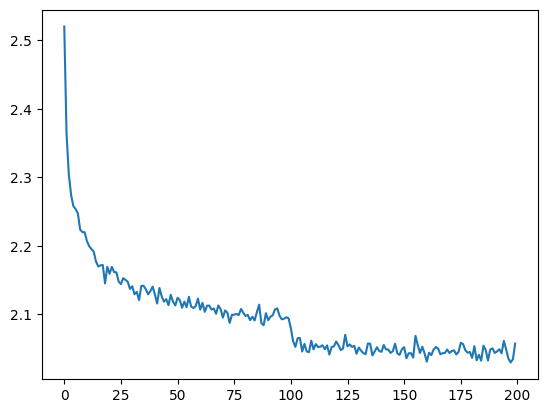

In [87]:
newlossi = torch.tensor(lossi).view(-1, 1_000).mean(dim=1)
plt.plot(newlossi)

# Change 2
### Pytorchifying embedding and concat embedding into classes

In [93]:
class Linear:
  def __init__(self, in_features, out_features, bias=True):
    self.w = torch.randn(in_features, out_features) / in_features**0.5
    self.b = torch.zeros(out_features) if bias else None

  def __call__(self, x):
    self.out = x @ self.w
    if self.b is not None:
      self.out += self.b
    return self.out

  def parameters(self):
    return [self.w] + ([self.b] if self.b is not None else [])

class BatchNorm1d:
  def __init__(self, num_features, eps=1e-5, momentum=0.001):
    self.bngain = torch.ones(num_features)
    self.bnbias = torch.zeros(num_features)
    self.training = True
    self.bnmean_running = torch.zeros(num_features)
    self.bnvar_running = torch.ones(num_features)
    self.eps = eps
    self.momentum = momentum

  def __call__(self, x):
    if self.training:
      bnmean = x.mean(dim=0, keepdim=True)
      bnvar = x.var(dim=0, keepdim=True)
    else:
      bnmean = self.bnmean_running
      bnvar = self.bnvar_running

    # Normalize the output after linear and before non-linear
    self.out = self.bngain * ((x-bnmean)/torch.sqrt(bnvar + self.eps)) + self.bnbias

    # Keep on adjusting overall mean and std, so that it could be used during evalutation or inference
    if self.training:
      with torch.no_grad():
        self.bnmean_running = (1-self.momentum)*self.bnmean_running + self.momentum*bnmean
        self.bnvar_running = (1-self.momentum)*self.bnvar_running + self.momentum*bnvar

    return self.out

  def parameters(self):
    return [self.bngain, self.bnbias]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.w = torch.randn(num_embeddings, embedding_dim)

  def __call__(self, x):
    self.out = self.w[x]
    return self.out

  def parameters(self):
    return [self.w]

class Flatten:
  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out

  def parameters(self):
    return []


In [94]:
n_embd = 10
n_hidden = 100

layers = [
    Embedding(vocab_size, n_embd), Flatten(),
    Linear(block_size*n_embd, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

parameters = [p for layer in layers for p in layer.parameters()]

with torch.no_grad():
  layers[-1].w *= 0.1

for p in parameters:
  p.requires_grad = True

print(sum([p.nelement() for p in parameters]))

11197


In [95]:
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  idx = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[idx], Ytr[idx]

  x = Xb
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, Yb)

  #Backward
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} {loss.item():.4f}")
  lossi.append(loss.item())

0/200000 3.3064
10000/200000 1.9396
20000/200000 2.0953
30000/200000 2.3726
40000/200000 1.9973
50000/200000 2.5788
60000/200000 2.3391
70000/200000 1.7066
80000/200000 1.8909
90000/200000 1.8515
100000/200000 2.1018
110000/200000 2.1883
120000/200000 2.4447
130000/200000 1.8012
140000/200000 1.6677
150000/200000 2.0806
160000/200000 1.9641
170000/200000 1.8155
180000/200000 1.9955
190000/200000 1.3166


In [96]:
# Set training to False for batchnorm
for layer in layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False

# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  for layer in layers:
    x = layer(x)
  logits = x
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0065548419952393
val 2.0639727115631104


In [97]:
# Inference

for _ in range(20):
  out = []
  context = [0]*block_size

  while True:
    x = torch.tensor([context])
    for layer in layers:
      x = layer(x)
    logits = x
    probs = F.softmax(logits, dim=1)
    idx = torch.multinomial(probs, num_samples=1, replacement=True).item()
    context = context[1:] + [idx] # Shifting by 1
    if idx == 0:
      break
    else:
      out.append(idx)
  print("".join([itos[i] for i in out]))

dresyn
calayah
jerepe
marryh
redoni
fort
samiel
nohamar
miko
azelona
danion
wizmin
tillie
marcyn
ishann
chilee
micheo
amondah
dielyssee
kynni


# Change 3
### Using container i.e. Sequential

In [105]:
class Linear:
  def __init__(self, in_features, out_features, bias=True):
    self.w = torch.randn(in_features, out_features) / in_features**0.5
    self.b = torch.zeros(out_features) if bias else None

  def __call__(self, x):
    self.out = x @ self.w
    if self.b is not None:
      self.out += self.b
    return self.out

  def parameters(self):
    return [self.w] + ([self.b] if self.b is not None else [])

class BatchNorm1d:
  def __init__(self, num_features, eps=1e-5, momentum=0.001):
    self.bngain = torch.ones(num_features)
    self.bnbias = torch.zeros(num_features)
    self.training = True
    self.bnmean_running = torch.zeros(num_features)
    self.bnvar_running = torch.ones(num_features)
    self.eps = eps
    self.momentum = momentum

  def __call__(self, x):
    if self.training:
      bnmean = x.mean(dim=0, keepdim=True)
      bnvar = x.var(dim=0, keepdim=True)
    else:
      bnmean = self.bnmean_running
      bnvar = self.bnvar_running

    # Normalize the output after linear and before non-linear
    self.out = self.bngain * ((x-bnmean)/torch.sqrt(bnvar + self.eps)) + self.bnbias

    # Keep on adjusting overall mean and std, so that it could be used during evalutation or inference
    if self.training:
      with torch.no_grad():
        self.bnmean_running = (1-self.momentum)*self.bnmean_running + self.momentum*bnmean
        self.bnvar_running = (1-self.momentum)*self.bnvar_running + self.momentum*bnvar

    return self.out

  def parameters(self):
    return [self.bngain, self.bnbias]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.w = torch.randn(num_embeddings, embedding_dim)

  def __call__(self, x):
    self.out = self.w[x]
    return self.out

  def parameters(self):
    return [self.w]

class Flatten:
  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out

  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [106]:
Xtr.shape, block_size

(torch.Size([182625, 8]), 8)

In [107]:
n_embd = 10
n_hidden = 200

model = Sequential([
    Embedding(vocab_size, n_embd), Flatten(),
    Linear(block_size*n_embd, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
  model.layers[-1].w *= 0.1

for p in model.parameters():
  p.requires_grad = True

print(sum([p.nelement() for p in model.parameters()]))

22097


In [108]:
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  idx = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[idx], Ytr[idx]
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  #Backward
  for p in model.parameters():
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 150_000 else 0.01
  for p in model.parameters():
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} {loss.item():.4f}")
  lossi.append(loss.item())

0/200000 3.3137
10000/200000 1.8869
20000/200000 2.1585
30000/200000 1.9761
40000/200000 2.4020
50000/200000 1.5264
60000/200000 1.7569
70000/200000 2.1315
80000/200000 2.1785
90000/200000 2.0433
100000/200000 2.6130
110000/200000 1.9086
120000/200000 2.4684
130000/200000 1.5363
140000/200000 1.7309
150000/200000 2.4010
160000/200000 2.1799
170000/200000 1.9574
180000/200000 1.8901
190000/200000 1.8315


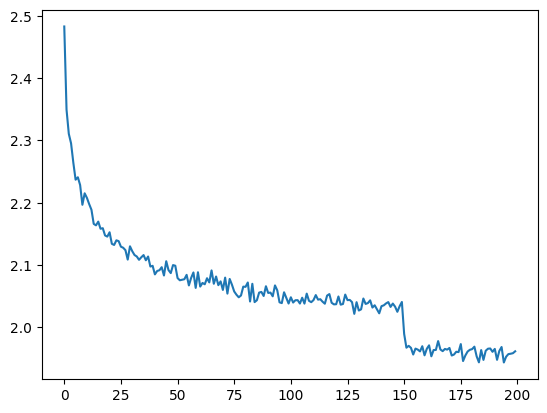

In [109]:
plt.plot(torch.tensor(lossi).view(-1,1_000).mean(dim=1))

In [110]:
# Set training to False for batchnorm
for layer in model.layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False

# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]

  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9157849550247192
val 2.02066707611084


In [111]:
# Inference

for _ in range(20):
  out = []
  context = [0]*block_size

  while True:
    x = torch.tensor([context])
    logits = model(x)
    probs = F.softmax(logits, dim=1)
    idx = torch.multinomial(probs, num_samples=1, replacement=True).item()
    context = context[1:] + [idx] # Shifting by 1
    if idx == 0:
      break
    else:
      out.append(idx)
  print("".join([itos[i] for i in out]))

juliyana
penoleen
julyaen
reefon
damenee
cesam
reelle
nyizah
javiel
kemithin
hannael
anelle
jarahri
kayn
acinda
ruwiss
asos
rnika
aspengy
harlo


### Loss Log

#### Before Wavenet
- Train: 1.91    Val: 2.02

#### After Wavenet
- Train: 1.81    Val: 1.99

# Implementing Wavenet style MLP

In [120]:
class Linear:
  def __init__(self, in_features, out_features, bias=True):
    self.w = torch.randn(in_features, out_features) / in_features**0.5
    self.b = torch.zeros(out_features) if bias else None

  def __call__(self, x):
    self.out = x @ self.w
    if self.b is not None:
      self.out += self.b
    return self.out

  def parameters(self):
    return [self.w] + ([self.b] if self.b is not None else [])

class BatchNorm1d:
  def __init__(self, num_features, eps=1e-5, momentum=0.001):
    self.bngain = torch.ones(num_features)
    self.bnbias = torch.zeros(num_features)
    self.training = True
    self.bnmean_running = torch.zeros(num_features)
    self.bnvar_running = torch.ones(num_features)
    self.eps = eps
    self.momentum = momentum

  def __call__(self, x):
    if self.training:
      ndim = x.dim
      usedims = 0
      if ndim == 2:
        usedims = 0 # Across batch
      elif ndim == 3:
        usedims = (0,1) # Across batch, and grams sub-batch

      bnmean = torch.mean(x, dim=usedims, keepdim=True)
      bnvar = torch.var(x, dim=usedims, keepdim=True)
    else:
      bnmean = self.bnmean_running
      bnvar = self.bnvar_running

    # Normalize the output after linear and before non-linear
    self.out = self.bngain * ((x-bnmean)/torch.sqrt(bnvar + self.eps)) + self.bnbias

    # Keep on adjusting overall mean and std, so that it could be used during evalutation or inference
    if self.training:
      with torch.no_grad():
        self.bnmean_running = (1-self.momentum)*self.bnmean_running + self.momentum*bnmean
        self.bnvar_running = (1-self.momentum)*self.bnvar_running + self.momentum*bnvar

    return self.out

  def parameters(self):
    return [self.bngain, self.bnbias]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.w = torch.randn(num_embeddings, embedding_dim)

  def __call__(self, x):
    self.out = self.w[x]
    return self.out

  def parameters(self):
    return [self.w]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, C, F = x.shape # Batch, chars, features
    flattened = x.view(x.shape[0], C//self.n, F*self.n)
    if flattened.shape[1] == 1:
      flattened = torch.squeeze(flattened, dim=1)
    self.out = flattened
    return self.out

  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
      #print(f"DEBUG {layer.__class__.__name__} {x.shape}")
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [121]:
# How To do fusion ?
# block size = 8 embedding = 24
# Xb [32, 8]
# C[Xb] [32, 8, 24]
# FlattenConsecutive (n=2) [32, 8//2, 24*2] (Basically whats happening we combine 2 char to make 4 bigrams)
# Linear(embedding*2, n_hidden) BatchNorm, Tanh
# FlattenConsecutive(n=2) [32, 4//2, n_hidden*2]
# Linear(n_hidden*2, n_hidden) BatchNorm Tanh
# FlattenConsecutive(n=2) [32, 2//1, n_hidden* 2] -> squeeze [32, n_hidden*2]
# Linear(n_hidden*2, n_hidden) BatchNorm Tanh
# Linear(n_hidden, vocab_size)

In [122]:
n_embd = 24
n_hidden = 128

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(n=2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(n=2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(n=2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
  model.layers[-1].w *= 0.1

for p in model.parameters():
  p.requires_grad = True

print(sum([p.nelement() for p in model.parameters()]))

76579


In [125]:
# Expected shapes
# L0 [32, 8, 24]
# L1 [32, 4, 48] L2 [32, 4, 128] L3 [32, 4, 128] L4 [32, 4, 128]
# L5 [32, 2, 256] L6 [32, 2, 128] L7 [32, 2, 128] L8 [32, 2, 128]
# L9 [32, 256] L10 [32, 128] L11 [32, 128] L12 [32, 128]
# L13 [32, 27]


#DEBUG Embedding torch.Size([32, 8, 24])
#DEBUG FlattenConsecutive torch.Size([32, 4, 48])
#DEBUG Linear torch.Size([32, 4, 128])
#DEBUG BatchNorm1d torch.Size([32, 4, 128])
#DEBUG Tanh torch.Size([32, 4, 128])
#DEBUG FlattenConsecutive torch.Size([32, 2, 256])
#DEBUG Linear torch.Size([32, 2, 128])
#DEBUG BatchNorm1d torch.Size([32, 2, 128])
#DEBUG Tanh torch.Size([32, 2, 128])
#DEBUG FlattenConsecutive torch.Size([32, 256])
#DEBUG Linear torch.Size([32, 128])
#DEBUG BatchNorm1d torch.Size([32, 128])
#DEBUG Tanh torch.Size([32, 128])
#DEBUG Linear torch.Size([32, 27])

In [126]:
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  idx = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[idx], Ytr[idx]
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  #Backward
  for p in model.parameters():
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 150_000 else 0.01
  for p in model.parameters():
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} {loss.item():.4f}")
  lossi.append(loss.item())

0/200000 3.3079
10000/200000 2.1650
20000/200000 2.1064
30000/200000 1.9932
40000/200000 2.1135
50000/200000 1.7164
60000/200000 2.0136
70000/200000 2.0258
80000/200000 2.2620
90000/200000 1.6417
100000/200000 1.8753
110000/200000 1.8147
120000/200000 1.7731
130000/200000 1.9265
140000/200000 1.9115
150000/200000 2.1117
160000/200000 1.6432
170000/200000 2.0611
180000/200000 2.1668
190000/200000 1.8908


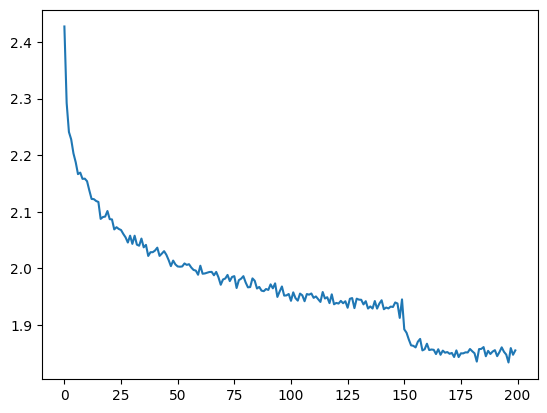

In [127]:
plt.plot(torch.tensor(lossi).view(-1,1_000).mean(dim=1))

In [128]:
# Set training to False for batchnorm
for layer in model.layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False

# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]

  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8072865009307861
val 1.9919565916061401


In [129]:
# Inference

for _ in range(20):
  out = []
  context = [0]*block_size

  while True:
    x = torch.tensor([context])
    logits = model(x)
    probs = F.softmax(logits, dim=1)
    idx = torch.multinomial(probs, num_samples=1, replacement=True).item()
    context = context[1:] + [idx] # Shifting by 1
    if idx == 0:
      break
    else:
      out.append(idx)
  print("".join([itos[i] for i in out]))

janessa
uzani
krix
hahfir
jaiyann
nayson
iraque
rhangelis
amara
retana
antiko
drishy
jaydin
nooby
ahsen
jalynn
zayvion
shantalynn
nassady
joneisa
